In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
ruta = 'https://raw.githubusercontent.com/jamc88/TSMA-II-26-O/refs/heads/main/Datos/panel_o3_temperatura_2025-2026.csv'

panel = pd.read_csv(ruta,parse_dates=["timestamp", "fecha"])

panel = panel.sort_values(["estacion", "timestamp"]).reset_index(drop=True)

serie_diaria = (
    panel
    .groupby("fecha", as_index=False)
    .agg(o3_promedio=("o3", "mean"), temperatura_promedio=("temperatura", "mean"))
    .sort_values("fecha")
    .reset_index(drop=True)
)

serie_diaria.head(10)

,fecha,o3_promedio,temperatura_promedio
0,2025-01-01,38.479167,13.431250
1,2025-01-02,26.750000,12.183333
2,2025-01-03,21.354167,11.675000
3,2025-01-04,24.187500,13.591667
4,2025-01-05,22.875000,13.752083
5,2025-01-06,18.739583,12.797917
6,2025-01-07,17.854167,14.368750
7,2025-01-08,20.781250,13.944792
8,2025-01-09,16.729167,15.522917
9,2025-01-10,21.982955,15.218750


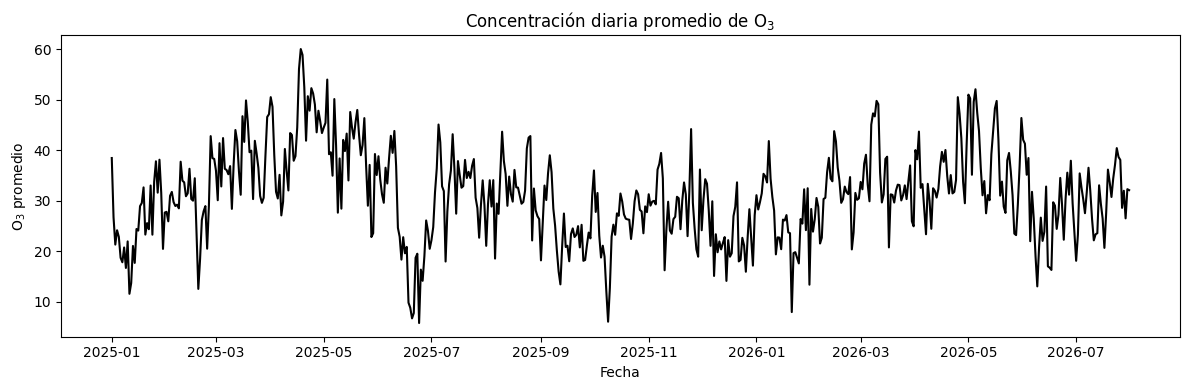

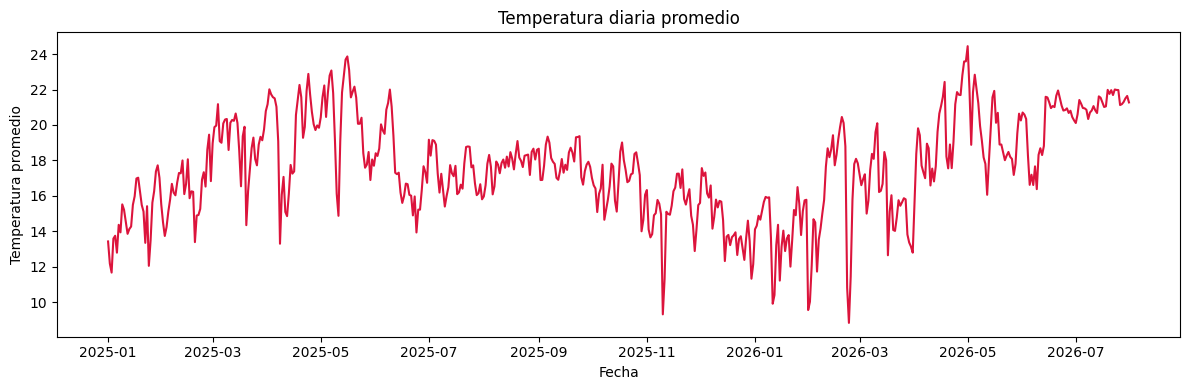

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["o3_promedio"],
    linewidth=1.5,
    color='black'
)

ax.set_title("Concentración diaria promedio de O$_3$")
ax.set_xlabel("Fecha")
ax.set_ylabel("O$_3$ promedio")

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["temperatura_promedio"],
    linewidth=1.5,
    color='crimson'
)

ax.set_title("Temperatura diaria promedio")
ax.set_xlabel("Fecha")
ax.set_ylabel("Temperatura promedio")

plt.tight_layout()
plt.show()

In [5]:
# Rezagos diarios de O3

serie_diaria["o3_lag_1"] = serie_diaria["o3_promedio"].shift(1) # 1 día

serie_diaria["o3_lag_7"] = serie_diaria["o3_promedio"].shift(7) # 7 días


# Rezagos diarios de temperatura

serie_diaria["temp_lag_1"] = serie_diaria["temperatura_promedio"].shift(1)

serie_diaria["temp_lag_3"] = serie_diaria["temperatura_promedio"].shift(3)

serie_diaria["temp_lag_7"] = serie_diaria["temperatura_promedio"].shift(7)


# Diferencias diarias

serie_diaria["delta_o3"] = serie_diaria["o3_promedio"].diff()

serie_diaria["delta_temp"] = serie_diaria["temperatura_promedio"].diff()


# Tasas de cambio porcentual

serie_diaria["cambio_pct_o3"] = serie_diaria["o3_promedio"].pct_change() * 100

serie_diaria["cambio_pct_temp"] = serie_diaria["temperatura_promedio"].pct_change() * 100

# Medias móviles de O3

serie_diaria["o3_media_3d"] = serie_diaria["o3_promedio"].rolling(window=3,min_periods=3).mean()

serie_diaria["o3_media_7d"] = serie_diaria["o3_promedio"].rolling(window=7,min_periods=7).mean()


# Medias móviles de temperatura

serie_diaria["temp_media_3d"] = serie_diaria["temperatura_promedio"].rolling(window=3,min_periods=3).mean()

serie_diaria["temp_media_7d"] = serie_diaria["temperatura_promedio"].rolling(window=7,min_periods=7).mean()


serie_diaria.head(10)

,fecha,o3_promedio,temperatura_promedio,o3_lag_1,o3_lag_7,temp_lag_1,temp_lag_3,temp_lag_7,delta_o3,delta_temp,cambio_pct_o3,cambio_pct_temp,o3_media_3d,o3_media_7d,temp_media_3d,temp_media_7d
0,2025-01-01,38.479167,13.431250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-02,26.750000,12.183333,38.479167,NaN,13.431250,NaN,NaN,-11.729167,-1.247917,-30.481862,-9.291143,NaN,NaN,NaN,NaN
2,2025-01-03,21.354167,11.675000,26.750000,NaN,12.183333,NaN,NaN,-5.395833,-0.508333,-20.171340,-4.172367,28.861111,NaN,12.429861,NaN
3,2025-01-04,24.187500,13.591667,21.354167,NaN,11.675000,13.431250,NaN,2.833333,1.916667,13.268293,16.416845,24.097222,NaN,12.483333,NaN
4,2025-01-05,22.875000,13.752083,24.187500,NaN,13.591667,12.183333,NaN,-1.312500,0.160417,-5.426357,1.180258,22.805556,NaN,13.006250,NaN
5,2025-01-06,18.739583,12.797917,22.875000,NaN,13.752083,11.675000,NaN,-4.135417,-0.954167,-18.078324,-6.938343,21.934028,NaN,13.380556,NaN
6,2025-01-07,17.854167,14.368750,18.739583,NaN,12.797917,13.591667,NaN,-0.885417,1.570833,-4.724847,12.274133,19.822917,24.319940,13.639583,13.114286
7,2025-01-08,20.781250,13.944792,17.854167,38.479167,14.368750,13.752083,13.431250,2.927083,-0.423958,16.394399,-2.950558,19.125000,21.791667,13.703819,13.187649
8,2025-01-09,16.729167,15.522917,20.781250,26.750000,13.944792,12.797917,12.183333,-4.052083,1.578125,-19.498747,11.316949,18.454861,20.360119,14.612153,13.664732
9,2025-01-10,21.982955,15.218750,16.729167,21.354167,15.522917,14.368750,11.675000,5.253788,-0.304167,31.404959,-1.959469,19.831124,20.449946,14.895486,14.170982


In [6]:
# Ventana móvil de 7 días

ventana_o3_7d = serie_diaria["o3_promedio"].rolling(window=7,min_periods=7)

# Características temporales

serie_diaria["o3_mediana_7d"] = ventana_o3_7d.median()

serie_diaria["o3_std_7d"] = ventana_o3_7d.std()

serie_diaria["o3_min_7d"] = ventana_o3_7d.min()

serie_diaria["o3_max_7d"] = ventana_o3_7d.max()

serie_diaria["o3_rango_7d"] = serie_diaria["o3_max_7d"] - serie_diaria["o3_min_7d"]

serie_diaria.head(10)

,fecha,o3_promedio,temperatura_promedio,o3_lag_1,o3_lag_7,temp_lag_1,temp_lag_3,temp_lag_7,delta_o3,delta_temp,...,cambio_pct_temp,o3_media_3d,o3_media_7d,temp_media_3d,temp_media_7d,o3_mediana_7d,o3_std_7d,o3_min_7d,o3_max_7d,o3_rango_7d
0,2025-01-01,38.479167,13.431250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-02,26.750000,12.183333,38.479167,NaN,13.431250,NaN,NaN,-11.729167,-1.247917,...,-9.291143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-01-03,21.354167,11.675000,26.750000,NaN,12.183333,NaN,NaN,-5.395833,-0.508333,...,-4.172367,28.861111,NaN,12.429861,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-01-04,24.187500,13.591667,21.354167,NaN,11.675000,13.431250,NaN,2.833333,1.916667,...,16.416845,24.097222,NaN,12.483333,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-01-05,22.875000,13.752083,24.187500,NaN,13.591667,12.183333,NaN,-1.312500,0.160417,...,1.180258,22.805556,NaN,13.006250,NaN,NaN,NaN,NaN,NaN,NaN
5,2025-01-06,18.739583,12.797917,22.875000,NaN,13.752083,11.675000,NaN,-4.135417,-0.954167,...,-6.938343,21.934028,NaN,13.380556,NaN,NaN,NaN,NaN,NaN,NaN
6,2025-01-07,17.854167,14.368750,18.739583,NaN,12.797917,13.591667,NaN,-0.885417,1.570833,...,12.274133,19.822917,24.319940,13.639583,13.114286,22.875000,6.955055,17.854167,38.479167,20.625000
7,2025-01-08,20.781250,13.944792,17.854167,38.479167,14.368750,13.752083,13.431250,2.927083,-0.423958,...,-2.950558,19.125000,21.791667,13.703819,13.187649,21.354167,3.096508,17.854167,26.750000,8.895833
8,2025-01-09,16.729167,15.522917,20.781250,26.750000,13.944792,12.797917,12.183333,-4.052083,1.578125,...,11.316949,18.454861,20.360119,14.612153,13.664732,20.781250,2.715041,16.729167,24.187500,7.458333
9,2025-01-10,21.982955,15.218750,16.729167,21.354167,15.522917,14.368750,11.675000,5.253788,-0.304167,...,-1.959469,19.831124,20.449946,14.895486,14.170982,20.781250,2.763382,16.729167,24.187500,7.458333


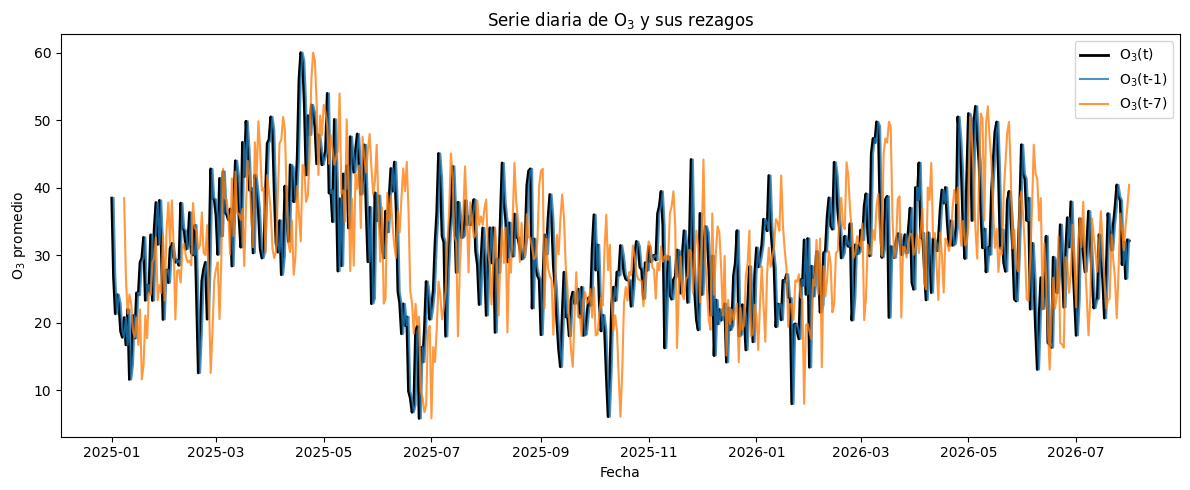

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["o3_promedio"],
    linewidth=2,
    label="O$_3$(t)",
    color='black'
)

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["o3_lag_1"],
    linewidth=1.5,
    alpha=0.8,
    label="O$_3$(t-1)"
)

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["o3_lag_7"],
    linewidth=1.5,
    alpha=0.8,
    label="O$_3$(t-7)"
)

ax.set_title("Serie diaria de O$_3$ y sus rezagos")

ax.set_xlabel("Fecha")
ax.set_ylabel("O$_3$ promedio")

ax.legend()

plt.tight_layout()
plt.show()

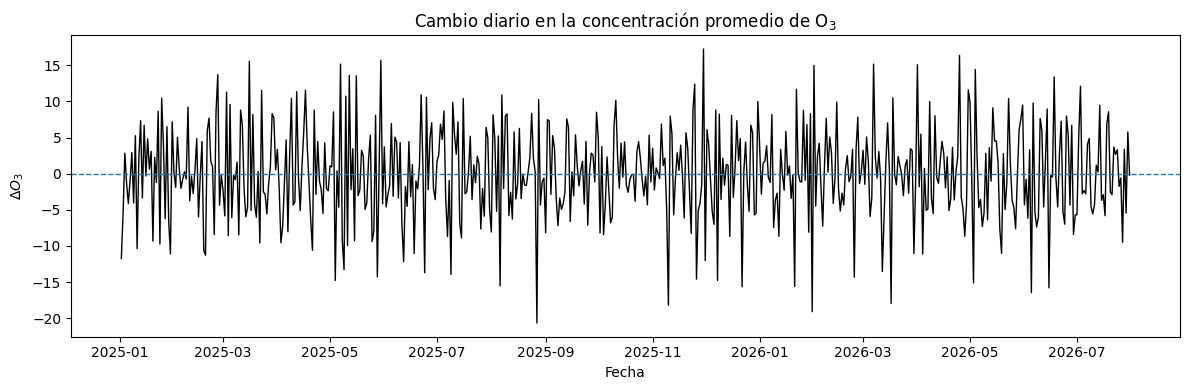

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["delta_o3"],
    linewidth=1,
    color='black'
)

ax.axhline(0,linestyle="--",linewidth=1)
ax.set_title("Cambio diario en la concentración promedio de O$_3$")
ax.set_xlabel("Fecha")
ax.set_ylabel(r"$\Delta O_3$")

plt.tight_layout()
plt.show()

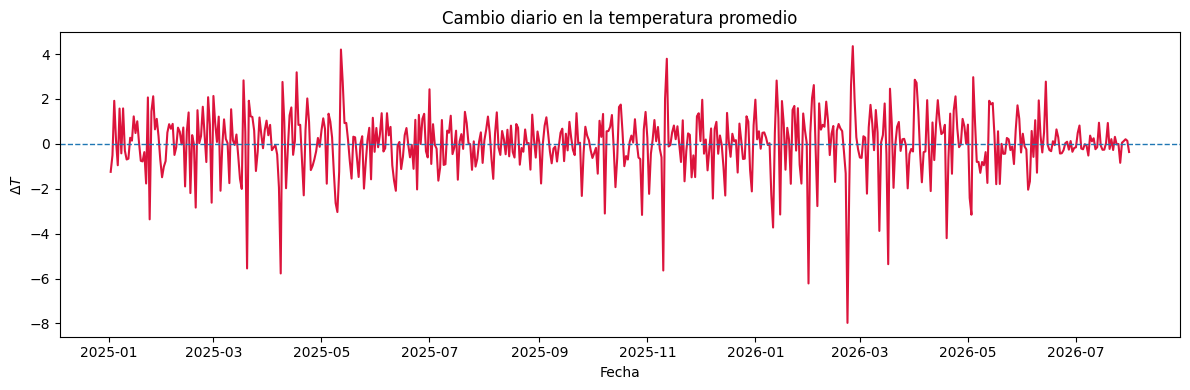

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["delta_temp"],
    linewidth=1.5,
    color='crimson'
)

ax.axhline(0,linestyle="--",linewidth=1)
ax.set_title("Cambio diario en la temperatura promedio")
ax.set_xlabel("Fecha")
ax.set_ylabel(r"$\Delta T$")

plt.tight_layout()
plt.show()

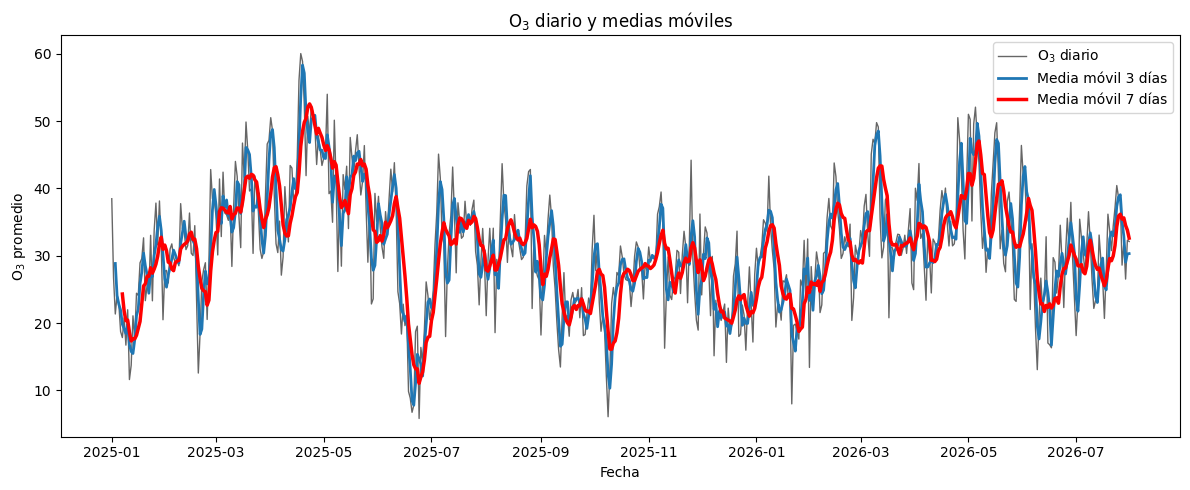

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["o3_promedio"],
    linewidth=1,
    alpha=0.6,
    label="O$_3$ diario",
    color='black'
)

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["o3_media_3d"],
    linewidth=2,
    label="Media móvil 3 días"
)

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["o3_media_7d"],
    linewidth=2.5,
    color='red',
    label="Media móvil 7 días"
)

ax.set_title("O$_3$ diario y medias móviles")

ax.set_xlabel("Fecha")
ax.set_ylabel("O$_3$ promedio")
ax.legend()

plt.tight_layout()
plt.show()

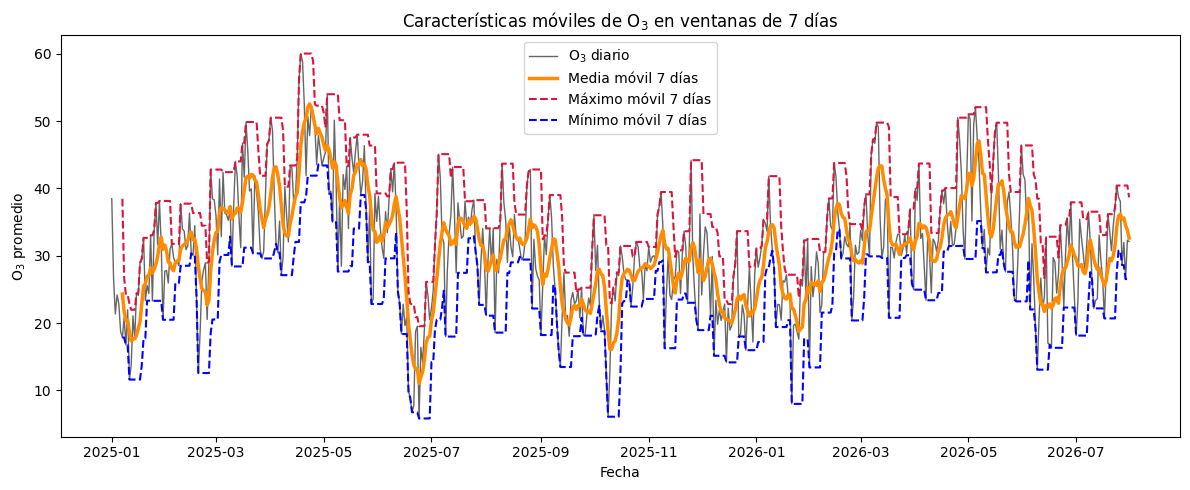

In [11]:
# Visualización del intervalo local de los últimos 7 días

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["o3_promedio"],
    linewidth=1,
    alpha=0.6,
    label="O$_3$ diario", color='black'
)

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["o3_media_7d"],
    linewidth=2.5,
    label="Media móvil 7 días", color='darkorange'
)

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["o3_max_7d"],
    linestyle="--",
    linewidth=1.5,
    label="Máximo móvil 7 días",color='crimson'
)

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["o3_min_7d"],
    linestyle="--",
    linewidth=1.5,
    label="Mínimo móvil 7 días",color='blue'
)

ax.set_title("Características móviles de O$_3$ en ventanas de 7 días")
ax.set_xlabel("Fecha")
ax.set_ylabel("O$_3$ promedio")
ax.legend()

plt.tight_layout()
plt.show()

## Ventanas móviles y fuga de información

Hasta ahora hemos calculado, por ejemplo, la media móvil de 7 días como

$$
\overline{Y}^{(7)}_t=
\frac{
Y_t+Y_{t-1}+\cdots+Y_{t-6}
}{7}.
$$

Esta definición es correcta cuando queremos **describir** el comportamiento reciente de la serie.

Sin embargo, existe un problema si queremos utilizar esta característica para predecir $Y_t$:

$$
\overline{Y}^{(7)}_t
$$

contiene al propio valor $Y_t$ que queremos predecir.

Esto produce **fuga de información** (*data leakage*).



### Ventana construida únicamente con el pasado

Para una tarea predictiva debemos utilizar solamente información disponible antes del instante $t$:

$$
\overline{Y}^{(7,\mathrm{pasado})}_t=
\frac{
Y_{t-1}+Y_{t-2}+\cdots+Y_{t-7}
}{7}.
$$

La diferencia es:

$$
\boxed{
\begin{aligned}
\text{Ventana descriptiva:}\quad
&Y_t,Y_{t-1},\ldots,Y_{t-6}\\[4pt]
\text{Ventana predictiva:}\quad
&Y_{t-1},Y_{t-2},\ldots,Y_{t-7}
\end{aligned}
}
$$


In [12]:
# Ventana predictiva: únicamente información pasada

o3_pasado = serie_diaria["o3_promedio"].shift(1)

ventana_pasada_7d = o3_pasado.rolling(window=7,min_periods=7)

# Características de los 7 días anteriores
serie_diaria["o3_media_prev_7d"] = ventana_pasada_7d.mean()

serie_diaria["o3_std_prev_7d"] = ventana_pasada_7d.std()

serie_diaria["o3_min_prev_7d"] = ventana_pasada_7d.min()

serie_diaria["o3_max_prev_7d"] = ventana_pasada_7d.max()

serie_diaria["o3_rango_prev_7d"] = serie_diaria["o3_max_prev_7d"] - serie_diaria["o3_min_prev_7d"]



# Comparación entre ventana descriptiva y predictiva

display(
    serie_diaria[
        [
            "fecha",
            "o3_promedio",
            "o3_media_7d",
            "o3_media_prev_7d",
            "o3_std_prev_7d",
            "o3_rango_prev_7d"
        ]
    ].head(10)
)

,fecha,o3_promedio,o3_media_7d,o3_media_prev_7d,o3_std_prev_7d,o3_rango_prev_7d
0,2025-01-01,38.479167,NaN,NaN,NaN,NaN
1,2025-01-02,26.750000,NaN,NaN,NaN,NaN
2,2025-01-03,21.354167,NaN,NaN,NaN,NaN
3,2025-01-04,24.187500,NaN,NaN,NaN,NaN
4,2025-01-05,22.875000,NaN,NaN,NaN,NaN
5,2025-01-06,18.739583,NaN,NaN,NaN,NaN
6,2025-01-07,17.854167,24.319940,NaN,NaN,NaN
7,2025-01-08,20.781250,21.791667,24.319940,6.955055,20.625000
8,2025-01-09,16.729167,20.360119,21.791667,3.096508,8.895833
9,2025-01-10,21.982955,20.449946,20.360119,2.715041,7.458333


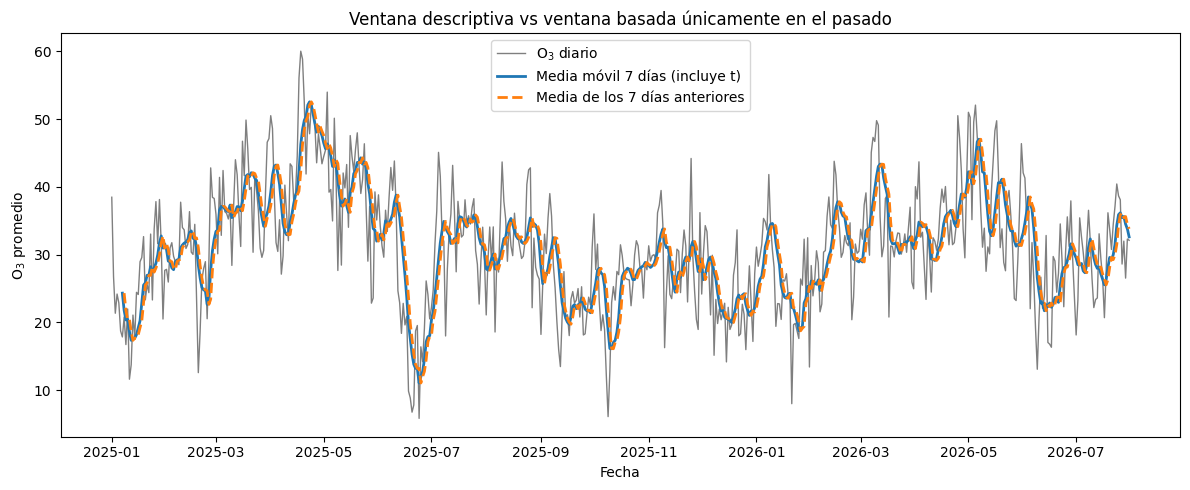

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["o3_promedio"],
    linewidth=1,
    alpha=0.5,
    label="O$_3$ diario", color='black'
)

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["o3_media_7d"],
    linewidth=2,
    label="Media móvil 7 días (incluye t)"
)

ax.plot(
    serie_diaria["fecha"],
    serie_diaria["o3_media_prev_7d"],
    linewidth=2,
    linestyle="--",
    label="Media de los 7 días anteriores"
)

ax.set_title("Ventana descriptiva vs ventana basada únicamente en el pasado")
ax.set_xlabel("Fecha")
ax.set_ylabel("O$_3$ promedio")
ax.legend()

plt.tight_layout()
plt.show()

## Relación entre O$_3$ y temperatura con rezagos

Hasta ahora hemos construido rezagos de una misma variable, por ejemplo,

$$
O_{3,t-1}.
$$

Sin embargo, los rezagos también pueden aplicarse a una variable que podría ayudar a explicar otra.

En nuestro caso podemos comparar la concentración de ozono del día $t$ con:

$$
T_t,
\qquad
T_{t-1},
\qquad
T_{t-3},
\qquad
T_{t-7}.
$$

Es decir:

- $T_t$: temperatura del mismo día;
- $T_{t-1}$: temperatura del día anterior;
- $T_{t-3}$: temperatura de tres días antes;
- $T_{t-7}$: temperatura de una semana antes.

Calcularemos la correlación de Spearman

$$
\rho_k
=
\operatorname{Corr}_S
\left(
O_{3,t},
T_{t-k}
\right)
$$

para diferentes valores de $k$.

Esto nos permite explorar si la asociación entre ambas variables es principalmente contemporánea o si también permanece cuando utilizamos información meteorológica del pasado.

Los resultados deben interpretarse de manera exploratoria:

$$
\boxed{\text{asociación temporal}\neq\text{causalidad}}
$$

y un rezago con mayor correlación no implica necesariamente que la temperatura de ese día sea la causa de los cambios observados en O$_3$.

In [14]:
# Correlación de Spearman entre O3 y temperatura para distintos rezagos

rezagos_temp = {
    0: "temperatura_promedio",
    1: "temp_lag_1",
    3: "temp_lag_3",
    7: "temp_lag_7"}

resultados_temp = []

for k, variable in rezagos_temp.items():

    rho = serie_diaria["o3_promedio"].corr(serie_diaria[variable],method="spearman")

    n = serie_diaria[["o3_promedio", variable]].dropna().shape[0]

    resultados_temp.append({
        "rezago_dias": k,
        "correlacion_spearman": rho,
        "n_observaciones": n
    })

correlaciones_temp = pd.DataFrame(resultados_temp)

print("Correlación O3(t) vs temperatura rezagada:")
correlaciones_temp.round(3)

Correlación O3(t) vs temperatura rezagada:


,rezago_dias,correlacion_spearman,n_observaciones
0,0,0.529,577
1,1,0.463,576
2,3,0.359,574
3,7,0.275,570


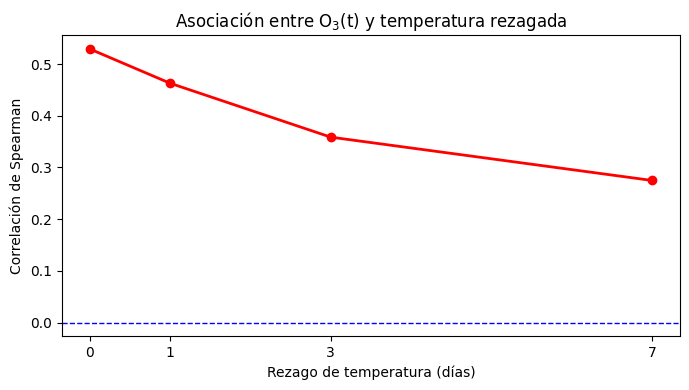

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    correlaciones_temp["rezago_dias"],
    correlaciones_temp["correlacion_spearman"],
    marker="o",
    linewidth=2,
    color='red'
)

ax.axhline(0,linestyle="--",linewidth=1, color='blue')
ax.set_xticks(correlaciones_temp["rezago_dias"])
ax.set_xlabel("Rezago de temperatura (días)")
ax.set_ylabel("Correlación de Spearman")
ax.set_title("Asociación entre O$_3$(t) y temperatura rezagada")

plt.tight_layout()
plt.show()



Durante el periodo analizado, la relación monotónica más fuerte se presenta con la temperatura del mismo día:

$$
\operatorname{Corr}_S(O_{3,t},T_t)=0.529.
$$


Sin embargo, la asociación disminuye al utilizar información más antigua, hasta ser muy débil para un rezago de siete días.

Esto sugiere que, en estos datos, la información meteorológica reciente contiene mayor asociación con el O$_3$ actual que la temperatura observada varios días antes.

Este resultado es exploratorio y no debe interpretarse como evidencia causal. Además, corresponde únicamente al periodo enero--febrero de 2026 y a las estaciones seleccionadas.

## Construcción de un conjunto de características temporales

A lo largo del notebook transformamos las series originales para obtener información sobre su comportamiento pasado.

Para cada día $t$ disponemos ahora de características como:

$$
O_{3,t-1},
\qquad
O_{3,t-7},
$$

$$
T_{t-1},
\qquad
T_{t-3},
\qquad
T_{t-7},
$$

así como características calculadas utilizando únicamente los siete días anteriores:

$$
\mu_{t-1:t-7},
\qquad
\sigma_{t-1:t-7},
\qquad
\min_{t-1:t-7},
\qquad
\max_{t-1:t-7},
\qquad
R_{t-1:t-7}.
$$

Podemos reunir esta información en una sola tabla:

$$
\boxed{
\mathbf{x}_t=
(
O_{3,t-1},
O_{3,t-7},
T_{t-1},
T_{t-3},
T_{t-7},
\mu_{t-1:t-7},
\sigma_{t-1:t-7},
R_{t-1:t-7}
)
}
$$

mientras que el valor que eventualmente podríamos intentar explicar o predecir sería

$$
y_t=O_{3,t}.
$$

Los primeros días tendrán valores faltantes porque todavía no existe suficiente historia temporal.

Por esta razón, para construir una tabla lista para modelado conservaremos únicamente las filas en las que todas las características estén disponibles.

In [16]:
# Variables que utilizarán como características

caracteristicas = [
    "o3_lag_1",
    "o3_lag_7",
    "temp_lag_1",
    "temp_lag_3",
    "temp_lag_7",
    "o3_media_prev_7d",
    "o3_std_prev_7d",
    "o3_min_prev_7d",
    "o3_max_prev_7d",
    "o3_rango_prev_7d"
]


# Tabla final

datos_temporales = (
    serie_diaria[
        ["fecha", "o3_promedio", "temperatura_promedio"]
        + caracteristicas
    ]
    .dropna()
    .reset_index(drop=True)
)

datos_temporales.head(10)

,fecha,o3_promedio,temperatura_promedio,o3_lag_1,o3_lag_7,temp_lag_1,temp_lag_3,temp_lag_7,o3_media_prev_7d,o3_std_prev_7d,o3_min_prev_7d,o3_max_prev_7d,o3_rango_prev_7d
0,2025-01-08,20.781250,13.944792,17.854167,38.479167,14.368750,13.752083,13.431250,24.319940,6.955055,17.854167,38.479167,20.625000
1,2025-01-09,16.729167,15.522917,20.781250,26.750000,13.944792,12.797917,12.183333,21.791667,3.096508,17.854167,26.750000,8.895833
2,2025-01-10,21.982955,15.218750,16.729167,21.354167,15.522917,14.368750,11.675000,20.360119,2.715041,16.729167,24.187500,7.458333
3,2025-01-11,11.614583,14.520833,21.982955,24.187500,15.218750,13.944792,13.591667,20.449946,2.763382,16.729167,24.187500,7.458333
4,2025-01-12,13.750000,13.860417,11.614583,22.875000,14.520833,15.522917,13.752083,18.653815,3.815088,11.614583,22.875000,11.260417
5,2025-01-13,21.083333,14.131250,13.750000,18.739583,13.860417,15.218750,12.797917,17.350244,3.689248,11.614583,21.982955,10.368371
6,2025-01-14,17.729167,14.272917,21.083333,17.854167,14.131250,14.520833,14.368750,17.685065,3.934553,11.614583,21.982955,10.368371
7,2025-01-15,24.437500,15.495833,17.729167,20.781250,14.272917,13.860417,13.944792,17.667208,3.933942,11.614583,21.982955,10.368371
8,2025-01-16,24.125000,15.977083,24.437500,16.729167,15.495833,14.131250,15.522917,18.189529,4.602268,11.614583,24.437500,12.822917
9,2025-01-17,28.958333,16.981250,24.125000,21.982955,15.977083,14.272917,15.218750,19.246077,5.039318,11.614583,24.437500,12.822917


In [17]:
print("Dimensiones antes de eliminar NaN:")
print(serie_diaria[["fecha", "o3_promedio"] + caracteristicas].shape)

print("\nDimensiones finales:")
print(datos_temporales.shape)


Dimensiones antes de eliminar NaN:
(577, 12)

Dimensiones finales:
(570, 13)


In [18]:
print("\nValores faltantes:")

print(
    datos_temporales
    .isna()
    .sum()
    .to_frame("n_faltantes"))


Valores faltantes:
                      n_faltantes
fecha                           0
o3_promedio                     0
temperatura_promedio            0
o3_lag_1                        0
o3_lag_7                        0
temp_lag_1                      0
temp_lag_3                      0
temp_lag_7                      0
o3_media_prev_7d                0
o3_std_prev_7d                  0
o3_min_prev_7d                  0
o3_max_prev_7d                  0
o3_rango_prev_7d                0


In [19]:
# Separación conceptual entre X e y

X = datos_temporales[
    caracteristicas
].copy()

y = datos_temporales[
    "o3_promedio"
].copy()

print("\nDimensiones de X:")
print(X.shape)

print("\nDimensiones de y:")
print(y.shape)


Dimensiones de X:
(570, 10)

Dimensiones de y:
(570,)


In [28]:
y

0      20.781250
1      16.729167
2      21.982955
3      11.614583
4      13.750000
         ...    
565    28.614583
566    32.000000
567    26.541667
568    32.312500
569    32.125000
Name: o3_promedio, Length: 570, dtype: float64

## De una serie temporal a un conjunto de datos para modelado

El procedimiento desarrollado en este notebook permitió transformar una serie temporal en un conjunto de características que resume su historia reciente.

Para cada día $t$, la variable que podríamos intentar explicar o predecir es

$$
y_t=O_{3,t},
$$

mientras que las variables de entrada son

$$
\mathbf{x}_t=
\left(
O_{3,t-1},
O_{3,t-7},
T_{t-1},
T_{t-3},
T_{t-7},
\mu^{(7)}_{t-1},
\sigma^{(7)}_{t-1},
\min^{(7)}_{t-1},
\max^{(7)}_{t-1},
R^{(7)}_{t-1}
\right).
$$

De esta forma pasamos conceptualmente de

$$
\boxed{\text{serie temporal}}
$$

a

$$
\boxed{\text{matriz de características } \mathbf{X}
\;+\;
\text{variable objetivo } \mathbf{y}}.
$$

La diferencia fundamental con un conjunto de datos convencional es que las características deben respetar el orden temporal.

Para predecir el día $t$ solamente podemos utilizar información conocida hasta

$$
t-1.
$$

Esta condición evita la fuga de información y será fundamental cuando construyamos modelos predictivos.



In [20]:
# Resumen del conjunto final

print("Conjunto final de características temporales")
print("-" * 48)

print(f"Número de observaciones: {len(datos_temporales)}")
print(f"Número de características: {len(caracteristicas)}")

print("\nPeriodo utilizable:")
print(
    datos_temporales["fecha"].min(),
    "→",
    datos_temporales["fecha"].max()
)

print("\nVariable objetivo:")
print("o3_promedio")

print("\nCaracterísticas:")
for variable in caracteristicas:
    print(f" - {variable}")

Conjunto final de características temporales
------------------------------------------------
Número de observaciones: 570
Número de características: 10

Periodo utilizable:
2025-01-08 00:00:00 → 2026-07-31 00:00:00

Variable objetivo:
o3_promedio

Características:
 - o3_lag_1
 - o3_lag_7
 - temp_lag_1
 - temp_lag_3
 - temp_lag_7
 - o3_media_prev_7d
 - o3_std_prev_7d
 - o3_min_prev_7d
 - o3_max_prev_7d
 - o3_rango_prev_7d


In [21]:
# Verificación temporal

print("\n¿Las fechas están ordenadas?")
print(datos_temporales["fecha"].is_monotonic_increasing)

print("\n¿Existen valores faltantes?")
print(
    datos_temporales
    .isna()
    .any()
    .any()
)


¿Las fechas están ordenadas?
True

¿Existen valores faltantes?
False


In [22]:
# Guardado

datos_temporales.to_csv(
    "datos_temporales_o3_2026.csv",
    index=False
)

print(
    "\nArchivo guardado como:"
    "\ndatos_temporales_o3_2026.csv"
)


Archivo guardado como:
datos_temporales_o3_2026.csv


# Ejercicio

Reproduzca el procedimiento desarrollado en este notebook modificando al menos uno de los siguientes elementos:

1. utilizar un periodo temporal más largo;
2. seleccionar otro contaminante;
3. trabajar con una estación individual en lugar del promedio de varias estaciones;
4. utilizar datos horarios en lugar de datos diarios.

Construya al menos:

$$
Y_{t-1},
\qquad
Y_{t-7},
\qquad
\Delta Y_t,
$$

una tasa de cambio y características obtenidas mediante una ventana móvil.

Para una ventana de $7$ periodos calcule:

$$
\text{media},
\qquad
\text{desviación estándar},
\qquad
\min,
\qquad
\max,
\qquad
\text{rango}.
$$

Finalmente, construya una tabla de características utilizando **únicamente información disponible antes del instante que se desea analizar**.

Explique brevemente:

- qué representa cada rezago;
- qué diferencia existe entre cambio absoluto y cambio porcentual;
- qué efecto produce aumentar el tamaño de una ventana móvil;
- por qué una ventana utilizada para predicción no debe incluir el valor del instante actual;
- cuántas observaciones se pierden al construir las características temporales.